## Purcae_Casestudy

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, and Seaborn libraries.
- Our main focus will be on key operations that are commonly used in these libraries.
- The following operations will be conducted on the CSV file:
  - Importing the necessary libraries.
  - Loading the dataset into the experiment.
  - Understanding the data in the file.
  - Performing data cleaning and visualization operations.
  - Preparing the data for further processing in the Data Science Life Cycle.

**Experment Link** --> https://colab.research.google.com/drive/1ikI_KB7Z3HvwBiufJqiW2FOxtP7Ii92Z?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1gCCI9wnKLVqqzHKCtQo-2h7_kdVK7A0k/view?usp=sharing




In [36]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Loading the data_set.
df = pd.read_csv("/content/purchase_data.csv")

In [38]:
# Understanding the data_set.
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,NaN,NaN,7969.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263014 non-null  object 
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          181501 non-null  float64
 10  Product_Category_3          80582 non-null   float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 24.1+ MB


In [40]:
df.shape

(263015, 12)

In [41]:
# checking for null values
df.isnull().sum()

,0
User_ID,0
Product_ID,1
Gender,1
Age,1
Occupation,1
City_Category,1
Stay_In_Current_City_Years,1
Marital_Status,1
Product_Category_1,1
Product_Category_2,81514


In [42]:
df.isnull().sum().sum()

np.int64(263956)

- We have total - 263956 null values in the dataset.

In [43]:
df['Product_Category_2'].fillna(0, inplace=True)
df['Product_Category_3'].fillna(0, inplace=True)

/tmp/ipykernel_7470/685169197.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Category_2'].fillna(0, inplace=True)
/tmp/ipykernel_7470/685169197.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

- We are using the 'fillna()' function to replace null values with '0'.

In [44]:
df.isnull().sum().sum()

np.int64(9)

- After filling null values, we still have 9 null values.

In [45]:
df = df.dropna()

- Now this null value count is not bigger then comparetive to dataset size.
- We are going to drop the null values with the 'dropna()' function.

In [46]:
df.isnull().sum().sum()

np.int64(0)

- Now the null value count is beccame'0'.

In [47]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

- In the info, the data in the 'Age' column dtype is object.
- Because the 'Age' column consists of '55+' by this, the dtype will show it as an object.

In [48]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

- Same in this 'Stay_In_Current_City_Years' column also consists of numbers, but it shows the dtype is object, because a '4+' value is there.

In [49]:
df['Age'] = df['Age'].replace('55+', '55')

df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace('4+', '4')

- To solve this problem, we are using the 'replace()' function to replace with the correct value.

In [50]:
df['Age'].unique()

array(['0-17', '55', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [51]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4', '3', '1', '0'], dtype=object)

- Now see that the problem in both columns is solved.

In [52]:
df['Stay_In_Current_City_Years'] = pd.to_numeric(df['Stay_In_Current_City_Years'],errors='coerce')

- We will convert the 'Stay_In_Current_City_Years' column from an object type to an integer type using the 'pd.to_numeric()' function.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263014 non-null  int64  
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 26.1+ MB


In [54]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [55]:
# Checking how many males and females are in the dataset.
df['Gender'].value_counts()

,count
Gender,
M,198488
F,64526


- Visualising how to make more purchases of products, male or female.
- For doing this, we are comparing the 'Age' and 'Purchase' columns.

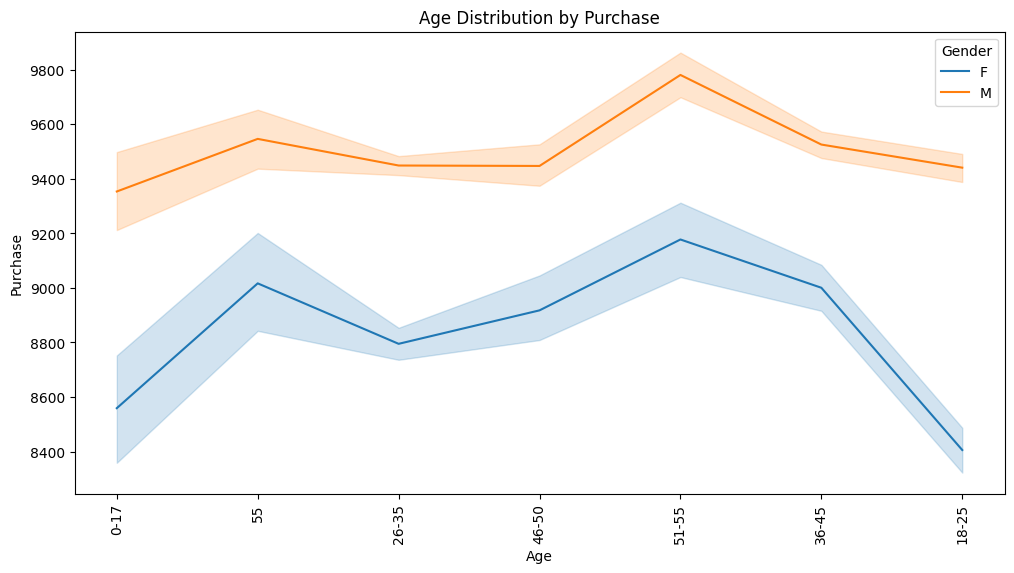

In [56]:
plt.figure(figsize=(12,6))
sns.lineplot(x="Age", y="Purchase", data=df,hue='Gender')
plt.xlabel('Age')
plt.ylabel('Purchase')
plt.title('Age Distribution by Purchase')
plt.xticks(rotation=90)
plt.show()

- By visualising 'Age' and 'Purchase', we can see that females make higher purchases.
- The age group of 51-55 years has been particularly active among females.

### Label Encoding:-
- By doing this labelencoding we are converting the object dtype columns into 'int' or 'float'.


In [57]:
#Importing the LabelEncoding from the sklearn library.
from sklearn.preprocessing import LabelEncoder

In [58]:
le = LabelEncoder()

In [59]:
for i in df.columns:
   if df[i].dtype == "object":
     df[i] = le.fit_transform(df[i])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  int64  
 2   Gender                      263014 non-null  int64  
 3   Age                         263014 non-null  int64  
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  int64  
 6   Stay_In_Current_City_Years  263014 non-null  int64  
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(6)
memory usage: 26.1 MB


- Now see all the object dtype columns converted into 'int' or 'float'.

1. It was observed that the average purchase made by men of the age 18-25 was 10000. Is it still the same?

In [61]:
male_data = df[(df['Age']==1) & (df['Gender'] == 1)]

In [62]:
male_data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
97,1000021,2024,1,1,16.0,1,0,0.0,3.0,12.0,0.0,3055.0
98,1000022,3261,1,1,15.0,0,4,0.0,1.0,8.0,17.0,12099.0
99,1000022,1954,1,1,15.0,0,4,0.0,5.0,8.0,0.0,8797.0
100,1000022,1792,1,1,15.0,0,4,0.0,3.0,4.0,0.0,10681.0
101,1000022,1020,1,1,15.0,0,4,0.0,8.0,14.0,0.0,7801.0


In [63]:
sample = male_data.sample(4500,random_state=5)

In [64]:
sample['Purchase'].mean()

np.float64(9445.31)